# MÓDULO 3 — Preprocesamiento e Ingeniería de Características
**Curso: Diagnóstico y Predictibilidad (92-0030)**
**Prof. Robin Sequeira | ULACIT**
Dataset: Superstore DS (`workspace.default.superstore`)

> **INSTRUCCIONES:** Este notebook continúa desde `df_clean` del Módulo 2. Ejecuta las celdas en orden de arriba hacia abajo.

### CELDA 1 — Punto de partida: cargar el dataset
*(Si ya tienes `df_clean` del Módulo 2, puedes saltar esta celda)*

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Carga desde la tabla Spark (misma fuente que Módulos 1 y 2)
spark_df = spark.table("workspace.diagnosticopredictibilidad.superstore")
pdf = spark_df.toPandas()
df_clean = pdf.copy()

print("Dataset cargado correctamente.")
print("Shape:", df_clean.shape)
print("Columnas:", df_clean.columns.tolist())

Dataset cargado correctamente.
Shape: (51290, 25)
Columnas: ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Region', 'Market', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority', 'Delivery Days', 'order year', 'order month']


### CELDA 2 — Clasificar las columnas del Superstore
*(Decisión humana: qué tipo es cada columna)*

In [0]:
# Columnas que usaremos como predictoras (excluimos IDs, fechas y texto de alta cardinalidad)
columnas_excluir = [
    "Order ID", "Order Date", "Ship Date",
    "Customer ID", "Customer Name",
    "Product ID", "Product Name",
    "City", "State", "Country"          # alta cardinalidad
]

# Variable objetivo
target = "Sales"

# Columnas numéricas (irán con StandardScaler)
num_cols = ["Quantity", "Discount", "Profit", "Shipping Cost", "Delivery Days"]

# Columnas categóricas (irán con OneHotEncoder)
cat_cols = ["Ship Mode", "Segment", "Category", "Order Priority", "Market"]

print("Variable objetivo:", target)
print("\nColumnas numéricas:", num_cols)
print("\nColumnas categóricas:", cat_cols)

Variable objetivo: Sales

Columnas numéricas: ['Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Delivery Days']

Columnas categóricas: ['Ship Mode', 'Segment', 'Category', 'Order Priority', 'Market']


### CELDA 3 — Preparar X (predictoras) e y (objetivo)

In [0]:
X = df_clean[num_cols + cat_cols].copy()
y = df_clean[target].copy()

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("\nPrimeras filas de X:")
X.head()

Shape de X: (51290, 10)
Shape de y: (51290,)

Primeras filas de X:


,Quantity,Discount,Profit,Shipping Cost,Delivery Days,Ship Mode,Segment,Category,Order Priority,Market
0,2,0.0,62,40,2,First Class,Consumer,Technology,High,USCA
1,9,0.1,-288,923,2,Second Class,Corporate,Furniture,Critical,Asia Pacific
2,9,0.1,919,915,1,First Class,Consumer,Technology,Medium,Asia Pacific
3,5,0.1,-96,910,2,First Class,Home Office,Technology,Medium,Europe
4,8,0.0,311,903,1,Same Day,Consumer,Technology,Critical,Africa


### CELDA 4 — Crear los transformadores individuales

In [0]:
# Para columnas numéricas: estandariza a media=0, desv. estándar=1
num_transformer = StandardScaler()

# Para columnas categóricas: genera una columna binaria por categoría
# handle_unknown='ignore' evita errores si en producción aparece una categoría nueva
cat_transformer = OneHotEncoder(handle_unknown="ignore")

print("Transformadores creados:")
print("  Numéricas  →", num_transformer)
print("  Categóricas →", cat_transformer)

Transformadores creados:
  Numéricas  → StandardScaler()
  Categóricas → OneHotEncoder(handle_unknown='ignore')


### CELDA 5 — Construir el ColumnTransformer
*(Aplica el transformador correcto a cada grupo de columnas)*

In [0]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),   # StandardScaler a columnas numéricas
        ("cat", cat_transformer, cat_cols)    # OneHotEncoder a columnas categóricas
    ],
    remainder="drop"    # descarta cualquier otra columna
)

print("ColumnTransformer configurado correctamente.")
print("Grupos:")
print("  Numéricas:", num_cols)
print("  Categóricas:", cat_cols)

ColumnTransformer configurado correctamente.
Grupos:
  Numéricas: ['Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Delivery Days']
  Categóricas: ['Ship Mode', 'Segment', 'Category', 'Order Priority', 'Market']


### CELDA 6 — Construir el Pipeline completo

In [0]:
pipe = Pipeline(steps=[
    ("prep", preprocessor)
])

print("Pipeline creado.")
print("Pasos:", [step[0] for step in pipe.steps])

Pipeline creado.
Pasos: ['prep']


### CELDA 7 — CORRECTO: Dividir PRIMERO, luego ajustar el Pipeline
*(Esto evita el data leakage)*

In [0]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("División completada:")
print("  X_train:", X_train.shape)
print("  X_test:", X_test.shape)
print("  y_train:", y_train.shape)
print("  y_test:", y_test.shape)

División completada:
  X_train: (41032, 10)
  X_test: (10258, 10)
  y_train: (41032,)
  y_test: (10258,)


### CELDA 8 — Ajustar y transformar con el Pipeline
*(fit SOLO con train, luego transform ambos conjuntos)*

In [0]:
# El Pipeline aprende solo con los datos de entrenamiento
X_train_t = pipe.fit_transform(X_train)

# Luego transforma el test usando lo que aprendió (sin verlo de nuevo)
X_test_t  = pipe.transform(X_test)

print("Pipeline aplicado correctamente.")
print("Shape X_train transformado:", X_train_t.shape)
print("Shape X_test transformado: ", X_test_t.shape)

# Todas las columnas son ahora numéricas
print("\nTipo de datos:", type(X_train_t))

Pipeline aplicado correctamente.
Shape X_train transformado: (41032, 24)
Shape X_test transformado:  (10258, 24)

Tipo de datos: <class 'numpy.ndarray'>


### CELDA 9 — ¿Qué columnas generó el OneHotEncoder?

In [0]:
# Nombres de las columnas generadas
cat_feature_names = pipe.named_steps["prep"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(cat_cols)

all_feature_names = num_cols + list(cat_feature_names)

print(f"Total columnas transformadas: {len(all_feature_names)}")
print("\nColumnas numéricas (sin cambio de nombre):", num_cols)
print("\nColumnas generadas por OneHotEncoder:")
for name in cat_feature_names:
    print(" ", name)

Total columnas transformadas: 24

Columnas numéricas (sin cambio de nombre): ['Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Delivery Days']

Columnas generadas por OneHotEncoder:
  Ship Mode_First Class
  Ship Mode_Same Day
  Ship Mode_Second Class
  Ship Mode_Standard Class
  Segment_Consumer
  Segment_Corporate
  Segment_Home Office
  Category_Furniture
  Category_Office Supplies
  Category_Technology
  Order Priority_Critical
  Order Priority_High
  Order Priority_Low
  Order Priority_Medium
  Market_Africa
  Market_Asia Pacific
  Market_Europe
  Market_LATAM
  Market_USCA


### CELDA 10 — Selección de características: correlación con Sales

In [0]:
# Calculamos correlación de Pearson de las variables numéricas con Sales
# (antes de transformar, sobre el dataset original para legibilidad)

corr_con_sales = df_clean[num_cols + [target]].corr()[target].drop(target)
corr_ordenada  = corr_con_sales.abs().sort_values(ascending=False)

print("Correlación absoluta de las numéricas con Sales:\n")
for col, val in corr_ordenada.items():
    estado = "✓ INCLUIR" if val > 0.2 else "✗ descartable"
    print(f"  {col:20s}: {corr_con_sales[col]:+.3f}  ({val:.3f})  {estado}")

print("\nUmbral aplicado: correlación absoluta > 0.2")

Correlación absoluta de las numéricas con Sales:

  Shipping Cost       : +0.768  (0.768)  ✓ INCLUIR
  Profit              : +0.485  (0.485)  ✓ INCLUIR
  Quantity            : +0.314  (0.314)  ✓ INCLUIR
  Discount            : -0.087  (0.087)  ✗ descartable
  Delivery Days       : -0.005  (0.005)  ✗ descartable

Umbral aplicado: correlación absoluta > 0.2


### CELDA 11 — Visualización: heatmap de correlaciones

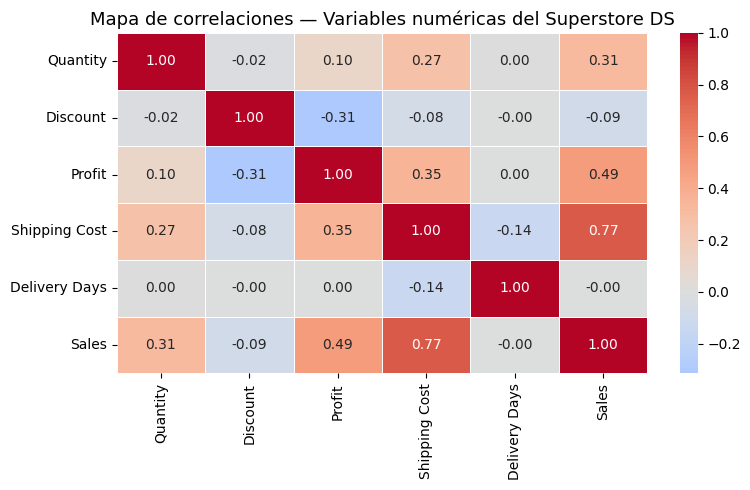

In [0]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))

corr_matrix = df_clean[num_cols + [target]].corr()

sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5,
    ax=ax
)

ax.set_title("Mapa de correlaciones — Variables numéricas del Superstore DS", fontsize=13)
plt.tight_layout()
plt.show()

### CELDA 12 — Filtrar columnas por umbral de correlación

In [0]:
UMBRAL = 0.2

# Columnas que superan el umbral
cols_seleccionadas = corr_con_sales[corr_con_sales.abs() > UMBRAL].index.tolist()
cols_descartadas   = corr_con_sales[corr_con_sales.abs() <= UMBRAL].index.tolist()

print(f"Columnas que pasan el filtro (|correlación| > {UMBRAL}):")
for col in cols_seleccionadas:
    print(f"  {col}: {corr_con_sales[col]:+.3f}")

print(f"\nColumnas descartables (|correlación| <= {UMBRAL}):")
for col in cols_descartadas:
    print(f"  {col}: {corr_con_sales[col]:+.3f}")

Columnas que pasan el filtro (|correlación| > 0.2):
  Quantity: +0.314
  Profit: +0.485
  Shipping Cost: +0.768

Columnas descartables (|correlación| <= 0.2):
  Discount: -0.087
  Delivery Days: -0.005


### CELDA 13 — Pipeline con solo las columnas seleccionadas
*(Reentrenamos con las columnas que pasaron el filtro de correlación)*

In [0]:
# Actualizamos las listas
num_cols_sel = [col for col in cols_seleccionadas]
# (las categóricas se mantienen; el filtro de correlación se aplica a numéricas)

print("Columnas numéricas seleccionadas:", num_cols_sel)
print("Columnas categóricas (sin cambio):", cat_cols)

# Pipeline con columnas filtradas
preprocessor_sel = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_sel),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="drop"
)

pipe_sel = Pipeline(steps=[("prep", preprocessor_sel)])

X_sel = df_clean[num_cols_sel + cat_cols].copy()

X_train_s, X_test_s, _, _ = train_test_split(X_sel, y, test_size=0.2, random_state=42)

X_train_final = pipe_sel.fit_transform(X_train_s)
X_test_final  = pipe_sel.transform(X_test_s)

print("\nShape final (columnas seleccionadas):", X_train_final.shape)
print("Listo para entrenar el modelo en módulos siguientes.")

Columnas numéricas seleccionadas: ['Quantity', 'Profit', 'Shipping Cost']
Columnas categóricas (sin cambio): ['Ship Mode', 'Segment', 'Category', 'Order Priority', 'Market']

Shape final (columnas seleccionadas): (41032, 22)
Listo para entrenar el modelo en módulos siguientes.


### CELDA 14 — Resumen del Módulo 3

In [0]:
print("=" * 55)
print("  RESUMEN DEL PREPROCESAMIENTO — Módulo 3")
print("=" * 55)
print()
print(f"Dataset original:         {df_clean.shape}")
print(f"Columnas numéricas usadas:  {num_cols}")
print(f"Columnas categóricas usadas: {cat_cols}")
print()
print(f"Después del Pipeline completo:")
print(f"  X_train transformado:   {X_train_t.shape}")
print(f"  X_test transformado:    {X_test_t.shape}")
print()
print(f"Después de selección por correlación (>{UMBRAL}):")
print(f"  X_train final:          {X_train_final.shape}")
print(f"  X_test final:           {X_test_final.shape}")
print()
print("Próximo paso: Módulo 4 — Fundamentos estadísticos")
print("  Usaremos este mismo dataset para estadística descriptiva,")
print("  distribuciones y heatmaps de correlación con seaborn.")
print("=" * 55)

  RESUMEN DEL PREPROCESAMIENTO — Módulo 3

Dataset original:         (51290, 25)
Columnas numéricas usadas:  ['Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Delivery Days']
Columnas categóricas usadas: ['Ship Mode', 'Segment', 'Category', 'Order Priority', 'Market']

Después del Pipeline completo:
  X_train transformado:   (41032, 24)
  X_test transformado:    (10258, 24)

Después de selección por correlación (>0.2):
  X_train final:          (41032, 22)
  X_test final:           (10258, 22)

Próximo paso: Módulo 4 — Fundamentos estadísticos
  Usaremos este mismo dataset para estadística descriptiva,
  distribuciones y heatmaps de correlación con seaborn.


### ***REFLEXION FINAL:***


### **1. ¿Qué aprendí?**

Aprendí que tener un dataset limpio no significa que esté listo para el modelo. Entendí cómo clasificar las variables y transformar las categóricas usando `OneHotEncoder` para crear columnas binarias, lo cual evita que el modelo asuma jerarquías falsas en datos de texto. También vi la importancia de usar `StandardScaler` en las numéricas para igualar sus escalas y evitar que una variable domine a otra por tener valores más grandes. También aprendí a filtrar características usando la correlación de Pearson para quedarme solo con lo que realmente predice el objetivo.

### **2. ¿Qué me costó más?**

Definitivamente, el concepto de *data leakage* (fuga de datos) y entender cómo un simple error en el orden de los pasos puede variar las métricas del modelo. Me tomó un rato procesar la regla de dividir los datos *antes* y hacer `fit_transform` estrictamente sobre el set de entrenamiento, usando solo `transform` en el de prueba. A nivel de código, estructurar el `ColumnTransformer` requiere mucho cuidado al asignar las listas de columnas (`num_cols` y `cat_cols`) a su transformador respectivo sin dejar datos perdidos.

### **3. ¿Dónde podría aplicar esto en mi realidad laboral?**

Este orden y estructura con `Pipeline` me puede servir para PoC predictivo, al procesar los grandes volúmenes de telemetría extraídos de GA4, puedo aplicar `OneHotEncoder`  para estandarizar el comportamiento o segmento de los usuarios. Además, encapsular todo el preprocesamiento en el pipeline me será de gran utilidad.